In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:
# ==========================================
# 1. Data Loading & Description
# ==========================================
# Simulating extraction from an Oracle SQL subscriber database
df = pd.read_csv("DATASET.csv")


In [6]:
# ==========================================
# 2. Data Cleaning & Feature Handling
# ==========================================
# Handling Null Values: We impute missing numeric billing data with the median to avoid skewing.
df['monthly_charges'] = df['monthly_charges'].fillna(df['monthly_charges'].median())
df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())
df.dropna(inplace=True) # Drop rows where critical ca

# Categorical Encoding
encoder = LabelEncoder()
categorical_cols = ['contract_type', 'payment_method', 'dtv_sachet_waiver_active']
for col in categorical_cols:
    if col in df.columns:
        df[col] = encoder.fit_transform(df[col])


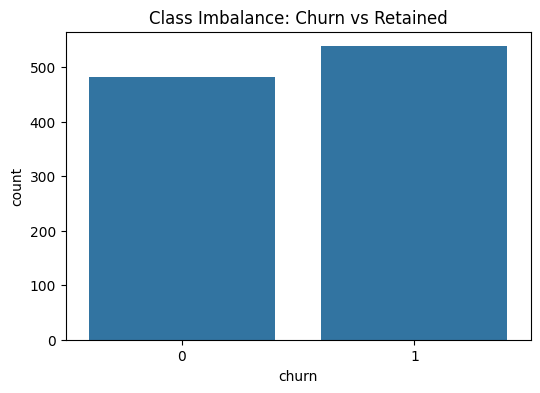

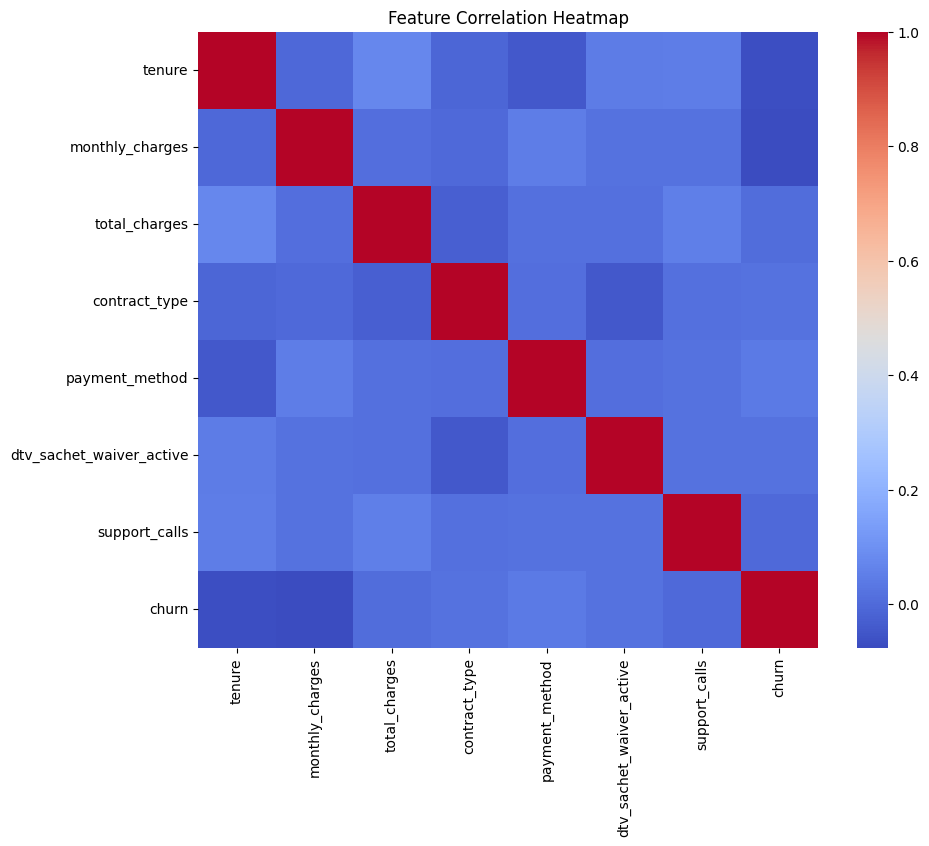

In [14]:
# ==========================================
# 3. Exploratory Data Analysis (EDA)
# ==========================================
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df)
plt.title('Class Imbalance: Churn vs Retained')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.drop('subscriber_id', axis=1).corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [15]:
# ==========================================
# 4. Model Implementation & Debugging
# ==========================================
X = df.drop(['churn', 'subscriber_id'], axis=1)
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression (Baseline)
# Debugging choice: Using class_weight='balanced' to handle the churn class imbalance
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Model 3: XGBoost (Advanced)
# Debugging choice: scale_pos_weight used instead of class_weight for XGBoost
xgb_model = XGBClassifier(scale_pos_weight=3, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [16]:
# ==========================================
# 5. Evaluation & Comparison
# ==========================================
models = {'Logistic Regression': log_model, 'Random Forest': rf_model, 'XGBoost': xgb_model}

for name, model in models.items():
    print(f"--- {name} ---")
    y_pred = model.predict(X_test_scaled)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred), "\n")


--- Logistic Regression ---
Accuracy: 0.5637254901960784
              precision    recall  f1-score   support

           0       0.51      0.60      0.55        91
           1       0.62      0.53      0.57       113

    accuracy                           0.56       204
   macro avg       0.57      0.57      0.56       204
weighted avg       0.57      0.56      0.56       204

[[55 36]
 [53 60]] 

--- Random Forest ---
Accuracy: 0.5637254901960784
              precision    recall  f1-score   support

           0       0.51      0.53      0.52        91
           1       0.61      0.59      0.60       113

    accuracy                           0.56       204
   macro avg       0.56      0.56      0.56       204
weighted avg       0.57      0.56      0.56       204

[[48 43]
 [46 67]] 

--- XGBoost ---
Accuracy: 0.5588235294117647
              precision    recall  f1-score   support

           0       0.51      0.41      0.45        91
           1       0.59      0.68      0.6

In [17]:
# ==========================================
# 6. Save the Best Model
# ==========================================
# Assuming XGBoost performs best on Recall for class 1 (Churn)
with open('best_model.pkl', 'wb') as file:
    pickle.dump({'model': xgb_model, 'scaler': scaler}, file)
